# **To What Extent Can Previous Olympic Performance Predict Future Medal Achievement?**

*Olympic Swimming Analysis (1968-2024)*

**Melina Yiangou**
**COMP-248-Project in Data Science**

 ## *Kaggle Datasets*

Dataset 1:[120 years of Olympic history: athletes and results][def]

Dataset 2:[Olympic Medal List (1896-2024)][def2]



## Research Questions
1. Does previous success predict future success?
2. Do athlete characteristics (age, height, weight) influence medal probability?
3. Does experience and prior medal history matter?
4. Does country strength influence medal predictability?

**Hypothesis:** Athletes with prior Olympic medals are significantly more likely to medal again.


[def]: https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results
[def2]: https://www.kaggle.com/datasets/amanrajput16/olympics-medal-list-1896-2024

In [ ]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded')

#Kaggle Datasets
athletes_df = pd.read_csv('https://drive.google.com/uc?id=1Ko8I0TSWGtAWnGmsS0zFeFXpP1cvDI1t')
medals_country_df = pd.read_csv('https://drive.google.com/uc?id=1s5Z5D4CRstisL7o7HhwuxbehTZgATjyo')
noc_region_df = pd.read_csv('https://drive.google.com/uc?id=1mPpEm8wfKaZSOi2x9yVaXuLL3fwStK4E')

print('Athletes dataset shape:', athletes_df.shape)
print('Country medals dataset shape:', medals_country_df.shape)
print('NOC regions dataset shape:', noc_region_df.shape)

Libraries loaded
Athletes dataset shape: (271116, 15)
Country medals dataset shape: (1436, 7)
NOC regions dataset shape: (230, 3)


## Data Filtering and Missing Medal Values Handling
Filtered to Swimming events from 1968 onwards. Butterfly was only introduced as a separate Olympic event in 1968, so both stroke groups start from the same year for consistency.

In [ ]:
#Merged Datasets for easier analysis
#Athlete events and Country Medals datasets.NOC is the common key
merged_df = athletes_df.merge(medals_country_df, on='NOC', how='left')

print('Merged dataset shape:', merged_df.shape)
merged_df.head()

#Filter to swimming events from 1968 onwards
swimming_df = merged_df[
    (merged_df['Sport'] == 'Swimming') &
    (merged_df['Year_x'] >= 1968)
].copy()
print('Swimming dataset shape:', swimming_df.shape)

#Handle missing Medal values by filling with 'None'
swimming_df['Medal'] = swimming_df['Medal'].fillna('None')
print('Medal distribution in swimming dataset:')
print(swimming_df['Medal'].value_counts())

#Separate freestyle and butterfly events excluding relays
print(swimming_df['Event'].unique())
print('\nTotal unique events:', swimming_df['Event'].nunique())
freestyle_events = [e for e in swimming_df['Event'].unique() 
                    if 'Freestyle' in e and 'Relay' not in e]

butterfly_events = [e for e in swimming_df['Event'].unique() 
                    if 'Butterfly' in e and 'Relay' not in e]

print('Freestyle events:')
for e in freestyle_events:
    print(' -', e)

print('\nButterfly events:')
for e in butterfly_events:
    print(' -', e)

Merged dataset shape: (271116, 21)
Swimming dataset shape: (18641, 21)
Medal distribution in swimming dataset:
Medal
None      16437
Gold        795
Silver      716
Bronze      693
Name: count, dtype: int64


In [ ]:
#Dataframes for each stroke
freestyle_df = swimming_df[swimming_df['Event'].isin(freestyle_events)].copy()
butterfly_df = swimming_df[swimming_df['Event'].isin(butterfly_events)].copy()

print('Freestyle rows:', freestyle_df.shape[0])
print('Butterfly rows:', butterfly_df.shape[0])

#Country strength feature: total medals won by each country in swimming
country_strength = (
    athletes_df[athletes_df['Medal'].notna()]
    .groupby('NOC')
    .size()
    .reset_index()
)
country_strength.columns = ['NOC', 'Country_Strength']

Freestyle rows: 5469
Butterfly rows: 2038


## Data Preprocessing
Preprocessing steps:
- Missing values in Age, Height, and Weight are imputed using the median
- Athletes are sorted chronologically by ID and year
- Three lag features are inserted to capture historical performance:
  - `Previous_Appearances` —> how many Olympics the athlete has competed in before this one
  - `Cumulative_Medals_Before` —>total medals won in all previous appearances
  - `Previous_Medal` — binary flag: has this athlete ever won a medal before?
- First-time appearances are removed since there is no prior history to learn from
- Country strength is derived from historical medal counts in the athletes dataset

These lag features help answer the hypothesis.If they directly impact past performance and its future prediction.

In [ ]:
def preprocess(df,country_strength):
    df = df.copy()
    
    #Fill missing values with median
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Height'] = df['Height'].fillna(df['Height'].median())
    df['Weight'] = df['Weight'].fillna(df['Weight'].median())
  
  #Target variable: 1 if won a medal, 0 otherwise
    df['Medal_Won'] = (df['Medal'] != 'None').astype(int)
    
#Sort by ID and Year to calculate previous appearances and medals
    df = df.sort_values(['ID', 'Year_x']).reset_index(drop=True)
    
    df['Previous_Appearances'] = df.groupby('ID').cumcount()
    df['Cumulative_Medals_Before'] = (
        df.groupby('ID')['Medal_Won']
        .cumsum()
        .shift(fill_value=0)
    )
    df['Previous_Medal'] = (df['Cumulative_Medals_Before'] > 0).astype(int)
  
  #Remove first appearances-no prior history available
  #Athletes with no prior appearances have no historical data
  #-to learn from, so they are exclude them from training
    df = df[df['Previous_Appearances'] > 0].copy()
  
  #Encode categorical variables
    le = LabelEncoder()
    df['Sex_enc'] = le.fit_transform(df['Sex'])
    df['Event_enc'] = le.fit_transform(df['Event'])

    #Numerical feature 
    df = df.merge(country_strength, on='NOC', how='left')
    df['Country_Strength'] = df['Country_Strength'].fillna(0)

    return df

freestyle_df = preprocess(freestyle_df, country_strength)
butterfly_df = preprocess(butterfly_df, country_strength)

print('Freestyle rows after preprocessing:', freestyle_df.shape[0])
print('Butterfly rows after preprocessing:', butterfly_df.shape[0])

Freestyle rows after preprocessing: 2693
Butterfly rows after preprocessing: 827


## Exploratory Data Analysis
Medal distribution and feature preview for both groups

In [ ]:
print('Freestyle with new features:')
print(freestyle_df[['Name', 'Year_x', 'Event', 'Age', 
                     'Previous_Appearances', 
                     'Cumulative_Medals_Before',
                     'Previous_Medal', 
                     'Medal_Won']].head(10).to_string())

print('\nButterfly with new features:')
print(butterfly_df[['Name', 'Year_x', 'Event', 'Age', 
                     'Previous_Appearances', 
                     'Cumulative_Medals_Before',
                     'Previous_Medal', 
                     'Medal_Won']].head(10).to_string())

In [ ]:
print('FREESTYLE Medal Distribution:')
print(freestyle_df['Medal_Won'].value_counts())
print(f'Medal rate: {freestyle_df["Medal_Won"].mean()*100:.1f}%')

print('\nBUTTERFLY Medal Distribution:')
print(butterfly_df['Medal_Won'].value_counts())
print(f'Medal rate: {butterfly_df["Medal_Won"].mean()*100:.1f}%')

## Classification Models
Two models are trained and evaluated separately for Freestyle and Butterfly:
- **Random Forest** —> ensemble of decision trees with class_weight='balanced' to handle the imbalance between medalists and non-medalists
- **Gradient Boosting** —> sequential ensemble that focuses on correcting previous errors

The dataset is split 80/20 for training and testing with stratification to preserve the medal ratio. Model performance is evaluated using AUC-ROC rather than accuracy alone, since accuracy is misleading when medals are rare (~9% of appearances).

In [ ]:

def run_models(df, group_name):
    print(f' {group_name}')

#Features to use for classification modeling    
    Features = [
        'Age', 'Height', 'Weight',
        'Sex_enc', 'Event_enc','Country_Strength',
        'Previous_Appearances',
        'Cumulative_Medals_Before',
        'Previous_Medal'
    ]
    
    X = df[Features]
    y = df['Medal_Won']
    #Stratified split to maintain balance in train/test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }
    
    for name, m in models.items():
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        y_proba = m.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f'\n {name} ')
        print(classification_report(y_test, y_pred, target_names=['No Medal', 'Medal']))
        print(f'AUC Score: {auc:.4f}')
    
    return models, X_test, y_test

freestyle_models, freestyle_X_test, freestyle_y_test = run_models(freestyle_df, 'FREESTYLE')
butterfly_models, butterfly_X_test, butterfly_y_test = run_models(butterfly_df, 'BUTTERFLY')

#AUC scores for each model summedarized
for name, m in freestyle_models.items():
    y_proba = m.predict_proba(freestyle_X_test)[:, 1]
    auc = roc_auc_score(freestyle_y_test, y_proba)
    print(f'Freestyle {name} AUC: {auc:.4f}')

for name, m in butterfly_models.items():
    y_proba = m.predict_proba(butterfly_X_test)[:, 1]
    auc = roc_auc_score(butterfly_y_test, y_proba)
    print(f'Butterfly {name} AUC: {auc:.4f}')

 FREESTYLE

 Random Forest 
              precision    recall  f1-score   support

    No Medal       0.94      0.99      0.96       493
       Medal       0.71      0.37      0.49        46

    accuracy                           0.93       539
   macro avg       0.83      0.68      0.72       539
weighted avg       0.92      0.93      0.92       539

AUC Score: 0.9045

 Gradient Boosting 
              precision    recall  f1-score   support

    No Medal       0.94      0.98      0.96       493
       Medal       0.63      0.37      0.47        46

    accuracy                           0.93       539
   macro avg       0.79      0.67      0.71       539
weighted avg       0.92      0.93      0.92       539

AUC Score: 0.9019
 BUTTERFLY

 Random Forest 
              precision    recall  f1-score   support

    No Medal       0.92      0.98      0.95       149
       Medal       0.62      0.29      0.40        17

    accuracy                           0.91       166
   macro avg   

## Country Performance Analysis
1. Top swimming nations performance over time
2. Whether athletes from historically stronger Olympic countries win medals at a higher rate

The country strength score is derived from total historical medals won per NOC in the athletes dataset, ensuring the codes match perfectly.

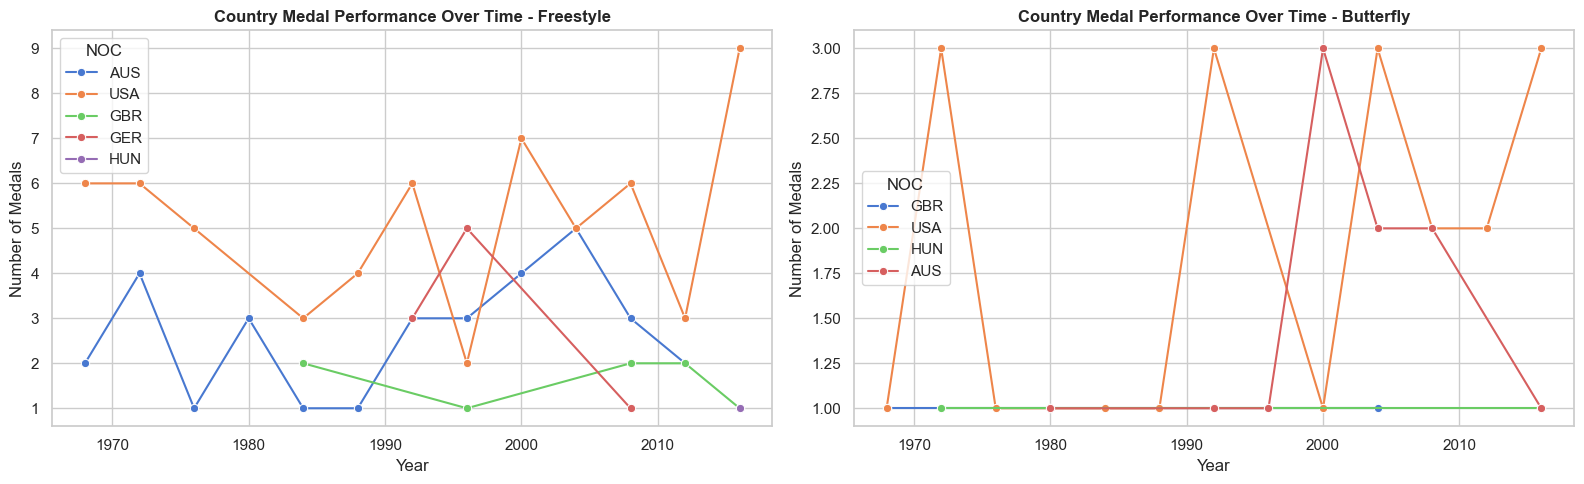

In [ ]:
#Time Plot
#Top 5 counties by medal count per year
top_countries = ['USA', 'AUS', 'GBR', 'GER', 'HUN']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, title) in zip(axes, [
    (freestyle_df, 'Freestyle'),
    (butterfly_df, 'Butterfly')
]):
    country_time = df[
        (df['NOC'].isin(top_countries)) &
        (df['Medal_Won'] == 1)
    ].groupby(['Year_x', 'NOC']).size().reset_index(name='Medal_Count')
    
    sns.lineplot(data=country_time, x='Year_x', y='Medal_Count',
                 hue='NOC', marker='o', ax=ax)
    ax.set_title(f'Country Medal Performance Over Time - {title}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Medals')

plt.tight_layout()
plt.show()

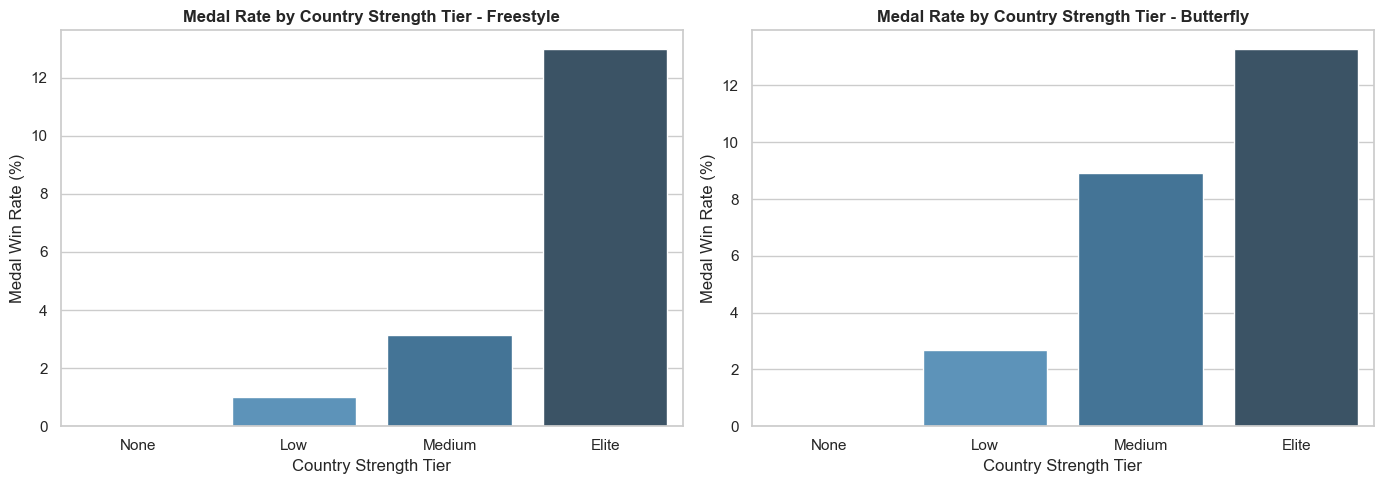

In [ ]:
# Tier plot
# Medal probability by country strength tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [
    (freestyle_df, 'Freestyle'),
    (butterfly_df, 'Butterfly')
]):
    df = df.copy()
    df['Strength_Tier'] = pd.cut(
        df['Country_Strength'],
        bins=[-1, 0, 50, 200, df['Country_Strength'].max()],
        labels=['None', 'Low', 'Medium', 'Elite']
    )
    
    medal_rate = df.groupby('Strength_Tier', observed=True)['Medal_Won'].mean().reset_index()
    medal_rate['Medal_Rate_%'] = medal_rate['Medal_Won'] * 100
    
    sns.barplot(data=medal_rate, x='Strength_Tier', y='Medal_Rate_%',
                palette='Blues_d', ax=ax)
    ax.set_title(f'Medal Rate by Country Strength Tier - {title}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Country Strength Tier')
    ax.set_ylabel('Medal Win Rate (%)')

plt.tight_layout()
plt.show()

## Threshold Tuning
By default, classifiers predict a medal when probability >= 0.5. Since medals are rare, lowering this threshold to 0.3 allows the model to catch more actual medalists at the cost of some false positives. This is evaluated using the best performing model for each stroke group.

In [33]:
def run_threshold(df, group_name, threshold=0.3):
    print(f'\n{group_name} - Threshold {threshold}')
    Features = [
        'Age', 'Height', 'Weight',
        'Sex_enc', 'Event_enc', 'Country_Strength',
        'Previous_Appearances',
        'Cumulative_Medals_Before',
        'Previous_Medal'
    ]
    X = df[Features]
    y = df['Medal_Won']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # Use best model per group
    if group_name == 'FREESTYLE':
        m = GradientBoostingClassifier(n_estimators=100, random_state=42)
    else:
        m = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    
    m.fit(X_train, y_train)
    y_proba = m.predict_proba(X_test)[:, 1]
    y_pred_adjusted = (y_proba >= threshold).astype(int)
    
    print(classification_report(y_test, y_pred_adjusted, 
                                 target_names=['No Medal', 'Medal']))
    auc = roc_auc_score(y_test, y_proba)
    print(f'AUC Score: {auc:.4f}')

run_threshold(freestyle_df, 'FREESTYLE', threshold=0.3)
run_threshold(butterfly_df, 'BUTTERFLY', threshold=0.3)


FREESTYLE - Threshold 0.3
              precision    recall  f1-score   support

    No Medal       0.96      0.96      0.96       493
       Medal       0.60      0.59      0.59        46

    accuracy                           0.93       539
   macro avg       0.78      0.78      0.78       539
weighted avg       0.93      0.93      0.93       539

AUC Score: 0.9019

BUTTERFLY - Threshold 0.3
              precision    recall  f1-score   support

    No Medal       0.94      0.94      0.94       149
       Medal       0.47      0.47      0.47        17

    accuracy                           0.89       166
   macro avg       0.71      0.71      0.71       166
weighted avg       0.89      0.89      0.89       166

AUC Score: 0.7874


## Visualizations
 *Model Evaluation*
 
ROC curves, feature importance, top countries, repeated medalists, and confusion matrices.

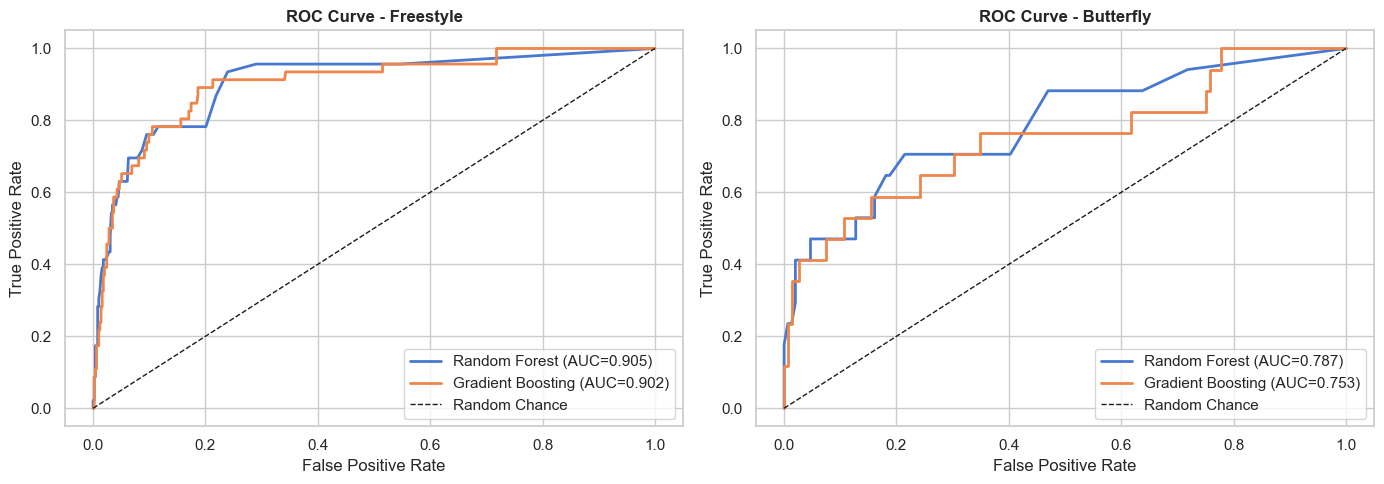

In [ ]:
#ROC Curves for both groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (models_dict, X_test, y_test, title) in zip(axes, [
    (freestyle_models, freestyle_X_test, freestyle_y_test, 'Freestyle'),
    (butterfly_models, butterfly_X_test, butterfly_y_test, 'Butterfly')
]):
    for name, m in models_dict.items():
        y_proba = m.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', lw=2)
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
    ax.set_title(f'ROC Curve - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

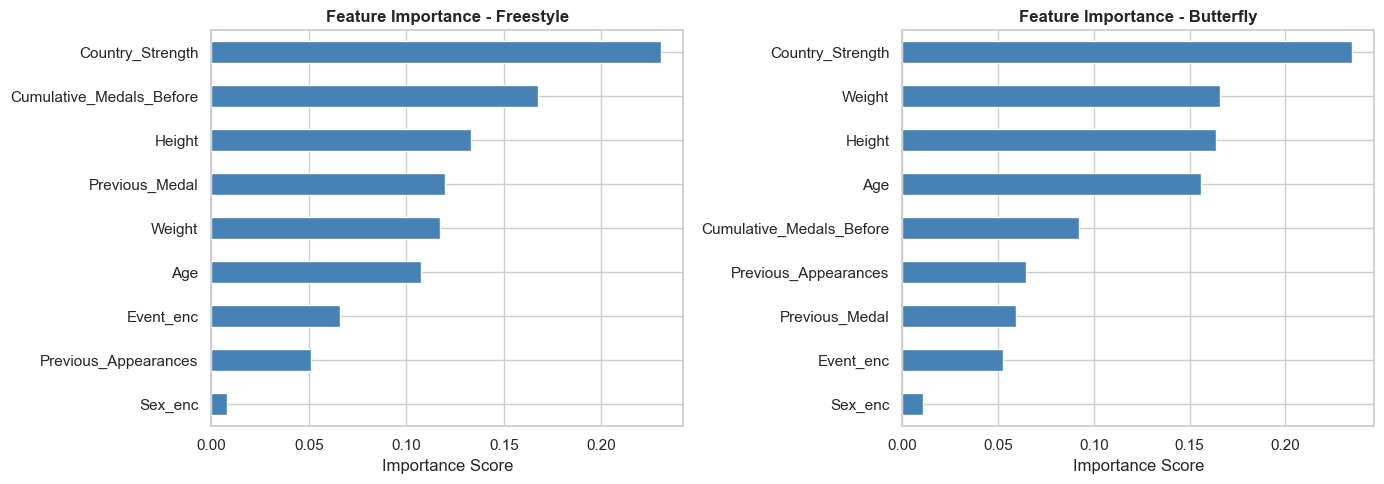

In [ ]:
#Feature importance for best model in each group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

freestyle_rf = freestyle_models['Random Forest']
butterfly_rf = butterfly_models['Random Forest']

Features = [
    'Age', 'Height', 'Weight',
    'Sex_enc', 'Event_enc', 'Country_Strength',
    'Previous_Appearances',
    'Cumulative_Medals_Before',
    'Previous_Medal'
]

for ax, (m, title) in zip(axes, [
    (freestyle_rf, 'Freestyle'),
    (butterfly_rf, 'Butterfly')
]):
    importances = pd.Series(m.feature_importances_, index=Features)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importance - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

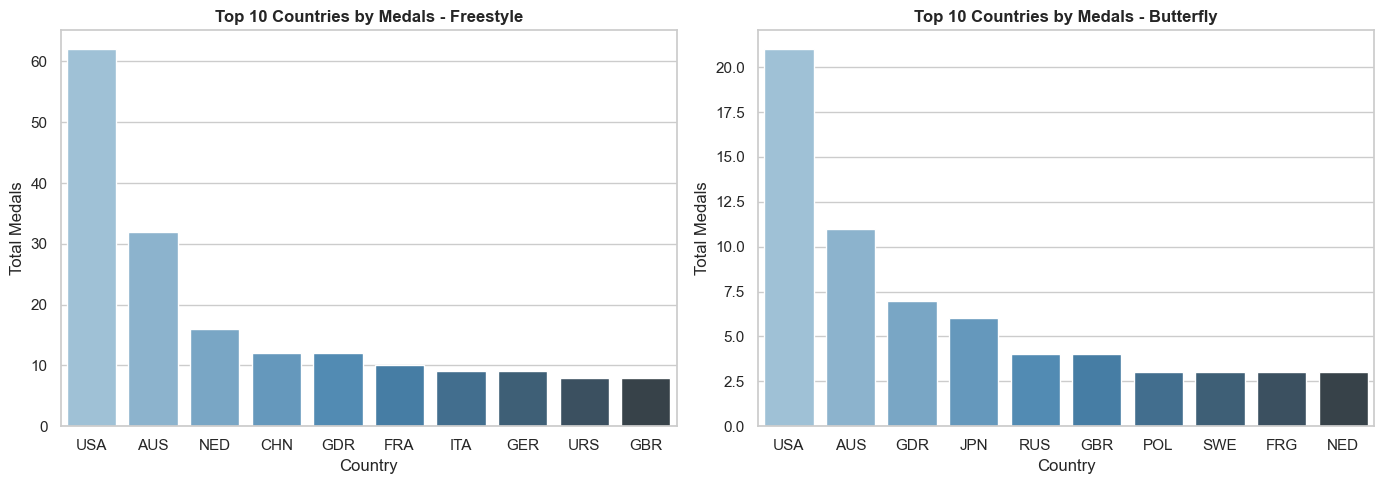

In [36]:
#Medal distribution by country
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [
    (freestyle_df, 'Freestyle'),
    (butterfly_df, 'Butterfly')
]):
    top_medals = (
        df[df['Medal_Won'] == 1]
        .groupby('NOC').size()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    top_medals.columns = ['NOC', 'Medal_Count']
    sns.barplot(data=top_medals, x='NOC', y='Medal_Count', 
                palette='Blues_d', ax=ax)
    ax.set_title(f'Top 10 Countries by Medals - {title}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Country')
    ax.set_ylabel('Total Medals')

plt.tight_layout()
plt.show()

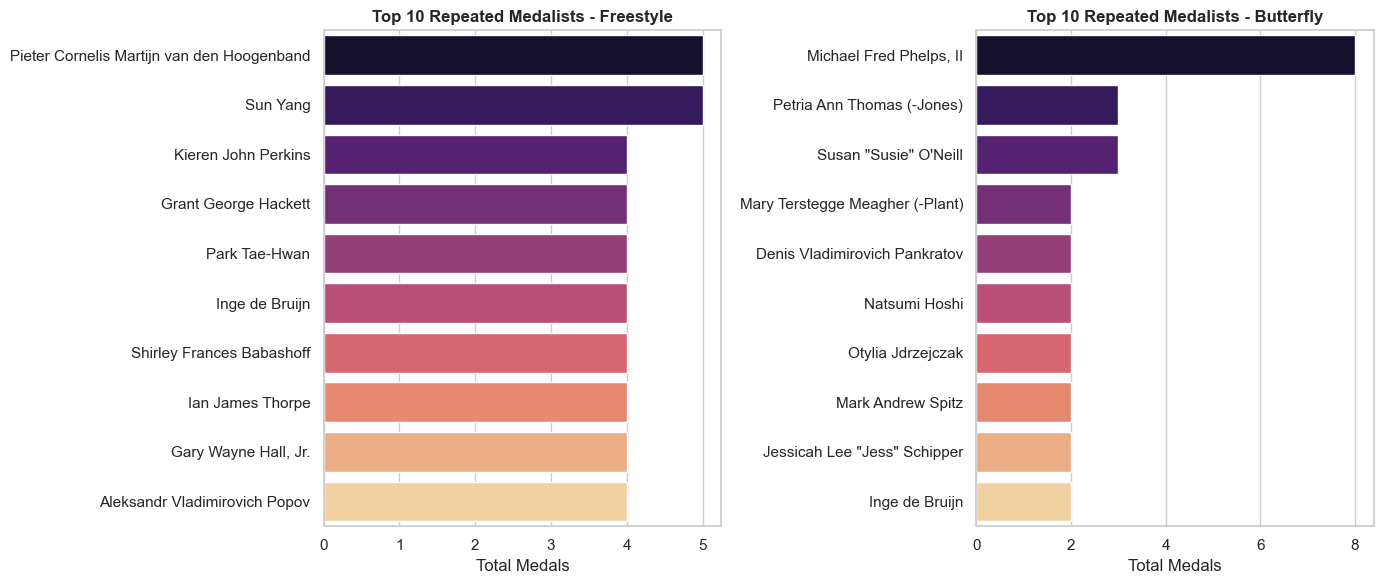

In [ ]:
#Repeated medalists and their medal counts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df, title) in zip(axes, [
    (freestyle_df, 'Freestyle'),
    (butterfly_df, 'Butterfly')
]):
    repeat = (
        df[df['Medal_Won'] == 1]
        .groupby('Name').size()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    repeat.columns = ['Name', 'Total_Medals']
    sns.barplot(data=repeat, y='Name', x='Total_Medals',
                palette='magma', ax=ax)
    ax.set_title(f'Top 10 Repeated Medalists - {title}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Total Medals')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

Confusion Matrices:
Shows the breakdown of correct and incorrect prediction

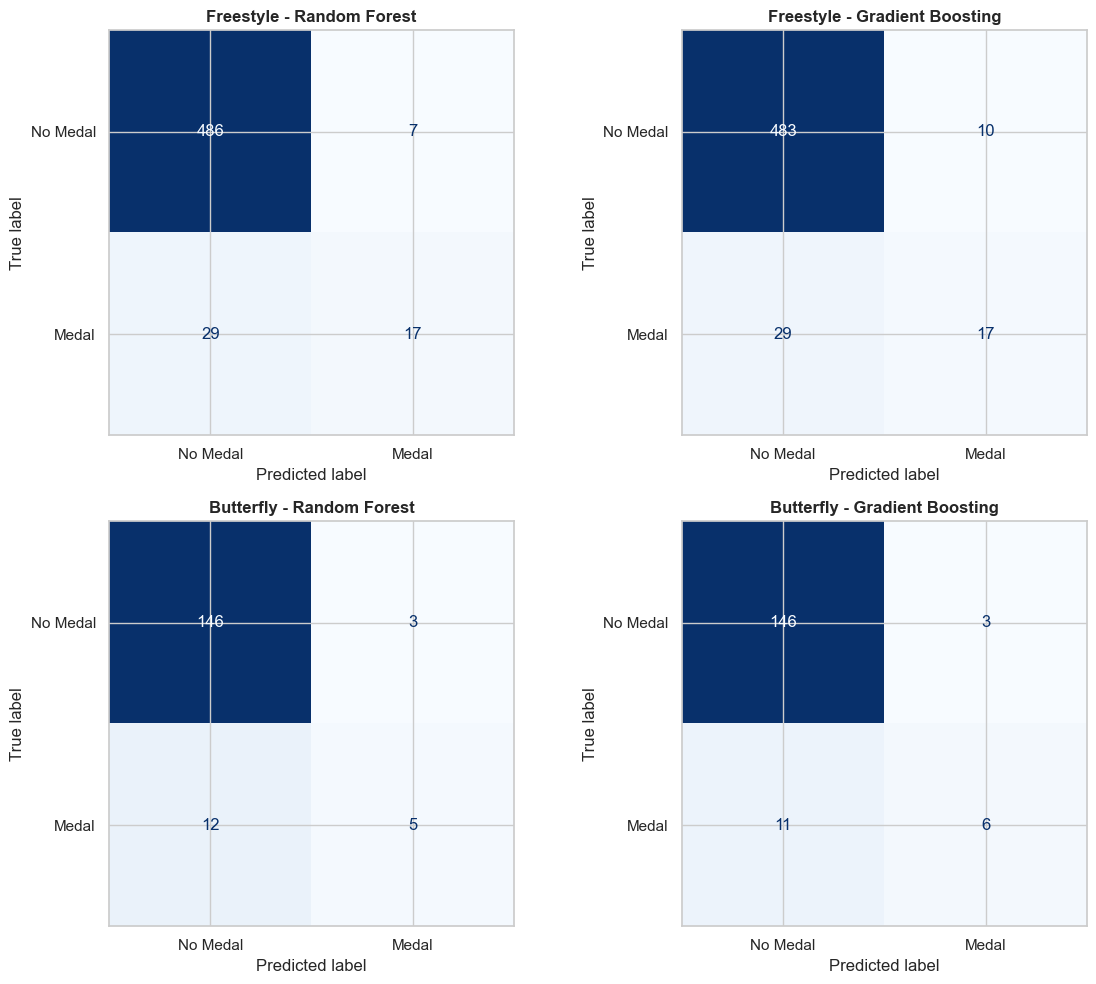

In [ ]:
#Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (models_dict, X_test, y_test, group) in enumerate([
    (freestyle_models, freestyle_X_test, freestyle_y_test, 'Freestyle'),
    (butterfly_models, butterfly_X_test, butterfly_y_test, 'Butterfly')
]):
    for j, (name, m) in enumerate(models_dict.items()):
        y_pred = m.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                       display_labels=['No Medal', 'Medal'])
        disp.plot(ax=axes[i][j], colorbar=False, cmap='Blues')
        axes[i][j].set_title(f'{group} - {name}', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusions

**1. Does previous success predict future success?**  
Yes. `Cumulative_Medals_Before` and `Previous_Medal` rank among the top features in both stroke groups, confirming that prior medal history is a strong predictor over time.

**2. Do athlete characteristics matter?**  
Age, height and weight contribute to the model but are less influential than performance history, suggesting physical attributes alone do not determine medal outcomes.

**3. Does experience and prior medals count?**  
Yes. `Previous_Appearances` and `Previous_Medal` are among the most important features, supporting the hypothesis that experienced repeat athletes have a higher medal probability.

**4. Does country strength influence medal predictability?**  
Yes. Athletes from Elite-tier countries show consistently higher medal rates than those from Low or None-tier countries, visible in both the tier plot and the top countries chart.

**Overall:** Both models achieve strong AUC scores (Freestyle ~0.90, Butterfly ~0.79), supporting the hypothesis that previous Olympic performance meaningfully predicts future medal achievement. The lower butterfly score shows that the dataset is smaller in size rather than a weaker relationship. The analysis confirms that past performance, particularly prior medals and experience, is the strongest predictor of future Olympic success.